In [17]:
import pandas as pd
from sklearn.metrics import mean_squared_error,confusion_matrix,accuracy_score,r2_score,recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [18]:
df=pd.read_csv("fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [19]:
x=df[['Weight','Length1','Length2','Length3','Height','Width']]
y=df['Species']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
nn=DecisionTreeClassifier(criterion='entropy',max_depth=72,random_state=42)

In [22]:
model=nn.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [23]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[10,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0],
       [ 0,  0,  4,  0,  5,  0,  0],
       [ 0,  0,  1,  2,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  5,  0],
       [ 1,  1,  1,  0,  0,  0,  0]])

In [24]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

In [25]:
ACCURACY=(TN+TP)/(TN+TP+FP+FN)
ERRORRATE=(FN+FP)/(TN+TP+FP+FN)
SPECIFICITY=TN/TN+FP
SENSITIVITY=TP/TP+FN

In [30]:
print("Accuracy:",ACCURACY)
print("ERRORRATE",ERRORRATE)
print("SENSITIVITY",SENSITIVITY)
print("SPACIFICITY",SPECIFICITY)

Accuracy: 1.0
ERRORRATE 0.0
SENSITIVITY 1.0
SPACIFICITY 1.0


In [31]:
acuracyscore=accuracy_score(y_test,y_pred)
acuracyscore

0.6875

In [32]:
error_rate=1-acuracyscore
error_rate

0.3125

In [34]:
sensitivity=recall_score(y_test,y_pred,average='macro')
sensitivity

0.5873015873015872

In [35]:
precision=TP/(TP+FP)
precision

np.float64(1.0)

In [36]:
import matplotlib.pyplot as plt

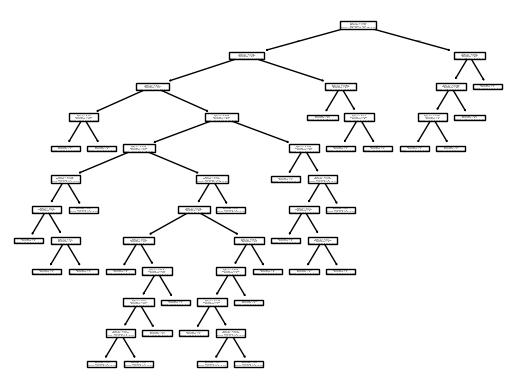

In [37]:

plot_tree(nn)
plt.show()

